# Task 4: Mining Insights from Customer Feedback
## G43 — Full Analysis Pipeline

**Structure:**
1. **EDA** — Data exploration & corpus understanding
2. **Preprocessing** — Text cleaning pipeline
3. **Part 1: Clustering Analysis** — KMeans/HAC on TF-IDF & SBERT
4. **Part 2: Topic Modelling & Sentiment** — Two design axes
5. **Evaluation** — Consistency, coherence, alignment
6. **Actionable Insights** — Final findings


In [1]:
%pip install kagglehub contractions gensim sentence-transformers nltk bertopic vaderSentiment textblob -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import numpy as np
import pandas as pd
import os, re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP
import nltk
import contractions
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.parsing.preprocessing import STOPWORDS
from sentence_transformers import SentenceTransformer
import gensim.downloader as api

# ML
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.decomposition import PCA, LatentDirichletAllocation
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr, spearmanr

# Sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# Settings
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

print("Loading models...")
skipgram_model = api.load('word2vec-google-news-300')
sbert = SentenceTransformer('all-MiniLM-L6-v2')
print("Models loaded.")


Loading models...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded.


# 1. Data Loading & Exploratory Data Analysis

In [3]:
download_path = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")
csv_path = os.path.join(download_path, "customer_support_tickets.csv")
df = pd.read_csv(csv_path, encoding='utf-8')
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset: 8469 rows, 17 columns


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


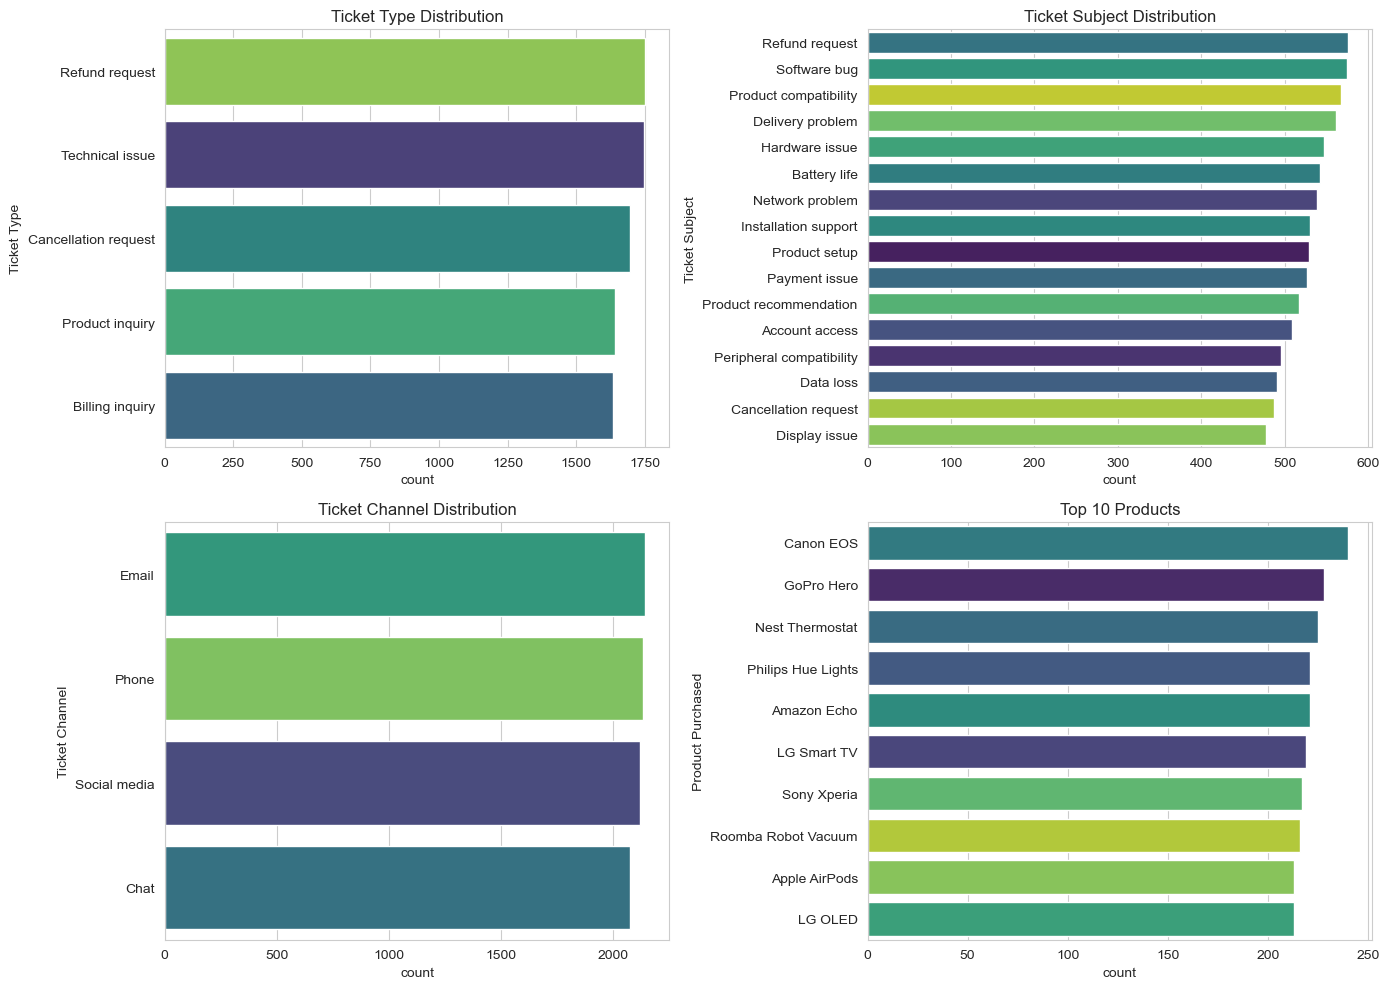

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, y='Ticket Type', order=df['Ticket Type'].value_counts().index,
              hue='Ticket Type', legend=False, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Ticket Type Distribution')
sns.countplot(data=df, y='Ticket Subject', order=df['Ticket Subject'].value_counts().index,
              hue='Ticket Subject', legend=False, palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Ticket Subject Distribution')
sns.countplot(data=df, y='Ticket Channel', order=df['Ticket Channel'].value_counts().index,
              hue='Ticket Channel', legend=False, palette='viridis', ax=axes[1,0])
axes[1,0].set_title('Ticket Channel Distribution')
top_products = df['Product Purchased'].value_counts().head(10).index
sns.countplot(data=df[df['Product Purchased'].isin(top_products)], y='Product Purchased',
              order=top_products, hue='Product Purchased', legend=False, palette='viridis', ax=axes[1,1])
axes[1,1].set_title('Top 10 Products')
plt.tight_layout()
plt.show()


In [5]:
print("=== Ticket Description Corpus Stats ===")
df['word_count'] = df['Ticket Description'].str.split().str.len()
print(f"Total tickets: {len(df)}")
print(f"Mean word count: {df['word_count'].mean():.1f}")
print(f"Template placeholders: {df['Ticket Description'].str.contains('{').sum()} / {len(df)} (100%)")
print(f"Social media handles: {df['Ticket Description'].str.contains(r'@\w+', regex=True).sum()}")
print(f"Missing Resolution: {df['Resolution'].isnull().sum()} ({df['Resolution'].isnull().mean()*100:.1f}%)")
print("\n=== Cross-tab: Ticket Type vs Priority ===")
print(pd.crosstab(df['Ticket Type'], df['Ticket Priority']))


=== Ticket Description Corpus Stats ===
Total tickets: 8469
Mean word count: 46.5
Template placeholders: 8469 / 8469 (100%)
Social media handles: 203
Missing Resolution: 5700 (67.3%)

=== Cross-tab: Ticket Type vs Priority ===
Ticket Priority       Critical  High  Low  Medium
Ticket Type                                      
Billing inquiry            420   382  398     434
Cancellation request       423   398  414     460
Product inquiry            403   399  398     441
Refund request             444   448  440     420
Technical issue            439   458  413     437


In [6]:
print("=== Sample Ticket Descriptions ===\n")
for i in range(5):
    print(f"--- Ticket {i} (Type: {df['Ticket Type'].iloc[i]}) ---")
    print(df['Ticket Description'].iloc[i][:300])
    print()


=== Sample Ticket Descriptions ===

--- Ticket 0 (Type: Technical issue) ---
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

--- Ticket 1 (Type: Technical issue) ---
I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.

--- Ticket 2 (Type: Technical issue) ---
I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.

1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging prope

In [7]:
def get_top_ngrams(df, ticket_type, n=2, top_k=8):
    texts = ' '.join(df[df['Ticket Type'] == ticket_type]['Ticket Description']).lower().split()
    return Counter(ngrams(texts, n)).most_common(top_k)

print("=== Top Bigrams by Ticket Type (Raw Text) ===")
for tt in df['Ticket Type'].unique():
    bigrams = get_top_ngrams(df, tt, n=2, top_k=5)
    formatted = [(' '.join(bg), c) for bg, c in bigrams]
    print(f"{tt:25s} → {formatted}")


=== Top Bigrams by Ticket Type (Raw Text) ===
Technical issue           → [('the {product_purchased}.', 1432), ('with the', 1338), ('issue with', 1330), ("i'm having", 1318), ('an issue', 1307)]
Billing inquiry           → [('the {product_purchased}.', 1295), ('with the', 1250), ('issue with', 1227), ("i'm having", 1212), ('an issue', 1207)]
Cancellation request      → [('the {product_purchased}.', 1351), ('with the', 1287), ('issue with', 1281), ("i'm having", 1278), ('an issue', 1257)]
Product inquiry           → [('the {product_purchased}.', 1295), ('issue with', 1234), ('with the', 1219), ("i'm having", 1212), ('an issue', 1195)]
Refund request            → [('the {product_purchased}.', 1390), ('issue with', 1322), ('with the', 1310), ("i'm having", 1302), ('an issue', 1293)]


# 2. Text Preprocessing Pipeline

In [8]:
def to_lower(text):
    return str(text).lower()

def expand_contractions_fn(text):
    return contractions.fix(text)

def replace_product_placeholder(text):
    return re.sub(r'\{product_purchased\}', 'PRODUCT', text, flags=re.IGNORECASE)

def remove_noise(text):
    text = re.sub(r'\S+@\S+\.\S+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\b\d{5}\b', '', text)
    text = re.sub(r'\b\d+(\.\d+)+\b', '', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_text(text):
    return word_tokenize(text)

custom_stopwords = frozenset([
    'please', 'help', 'thank', 'thanks', 'hi', 'hello',
    'dear', 'regards', 'appreciate', 'kindly',
    'issue', 'problem', 'assist', 'experiencing', 'need',
    'having', 'facing', 'would', 'could', 'get', 'got',
    'also', 'using', 'use', 'let', 'know', 'like', 'one',
    'set', 'add',
    'try', 'tried', 'trying', 'want', 'wanted',
    'work', 'working', 'resolve', 'resolved',
    'look', 'looking', 'go', 'going', 'keep',
    'take', 'make', 'making', 'able', 'unable',
    'receive', 'received', 'provide', 'provided',
    'product', 'customer', 'service', 'support',
    'team', 'response', 'request', 'information',
    'time', 'day', 'week',
    'since', 'still', 'even', 'much',
    'really', 'already', 'just', 'yet',
    'update', 'device', 'data', 'software', 'account',
    'step', 'persists', 'perform', 'troubleshoot', 'contact',
    'start', 'notice', 'fine', 'check', 'multiple',
    'available', 'productivity', 'reset', 'option',
    'change', 'say', 'possible', 'specific', 'action',
])

def remove_stopwords_all(tokens):
    return [w for w in tokens if w not in STOPWORDS and w not in custom_stopwords]

def filter_short_tokens(tokens, min_len=3):
    return [t for t in tokens if len(t) >= min_len]

lemmatizer = WordNetLemmatizer()
tag_map = {'J': 'a', 'V': 'v', 'N': 'n', 'R': 'r'}

def lemmatize_tokens(tokens):
    tagged = pos_tag(tokens)
    return [lemmatizer.lemmatize(token, tag_map.get(tag[0].upper(), 'n'))
            for token, tag in tagged]

print("Preprocessing functions defined.")


Preprocessing functions defined.


In [9]:
bow_vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=5000, max_df=0.85)
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=3, max_df=0.85)

def vectorize_skipgram(token_lists):
    embeddings = []
    for tokens in token_lists:
        vecs = [skipgram_model[t] for t in tokens if t in skipgram_model]
        embeddings.append(np.mean(vecs, axis=0) if vecs else np.zeros(300))
    return np.array(embeddings)

def preprocess_text(df):
    text = df['Ticket Description'].copy()
    text = text.apply(to_lower)
    text = text.apply(expand_contractions_fn)
    text = text.apply(replace_product_placeholder)
    text = text.apply(remove_noise)
    sbert_text = text.copy()
    tokens = text.apply(tokenize_text)
    tokens = tokens.apply(remove_stopwords_all)
    tokens = tokens.apply(filter_short_tokens)
    tokens = tokens.apply(lemmatize_tokens)
    return tokens, sbert_text

def build_all_representations(df):
    tokens, sbert_text = preprocess_text(df)
    clean_text = tokens.apply(lambda t: ' '.join(t))
    print("Building BoW...", end=" ")
    X_bow = bow_vectorizer.fit_transform(clean_text)
    print(f"shape: {X_bow.shape}")
    print("Building TF-IDF...", end=" ")
    X_tfidf = tfidf_vectorizer.fit_transform(clean_text)
    print(f"shape: {X_tfidf.shape}")
    print("Building Skipgram...", end=" ")
    X_skipgram = vectorize_skipgram(tokens.tolist())
    print(f"shape: {X_skipgram.shape}")
    print("Building SBERT...", end=" ")
    X_sbert = sbert.encode(sbert_text.tolist(), show_progress_bar=True, batch_size=64)
    print(f"shape: {X_sbert.shape}")
    return X_bow, X_tfidf, X_skipgram, X_sbert, tokens, clean_text

X_bow, X_tfidf, X_skipgram, X_sbert, tokens, clean_text = build_all_representations(df)


Building BoW... shape: (8469, 5000)
Building TF-IDF... shape: (8469, 3642)
Building Skipgram... shape: (8469, 300)
Building SBERT... 

Batches:   0%|          | 0/133 [00:00<?, ?it/s]

shape: (8469, 384)


In [10]:
print("=== Top 5 TF-IDF Features per Ticket Type ===")
feature_names = tfidf_vectorizer.get_feature_names_out()
for ticket_type in df['Ticket Type'].unique():
    mask = (df['Ticket Type'] == ticket_type).values
    type_mean = X_tfidf[mask].mean(axis=0).A1
    top_5 = type_mean.argsort()[-5:][::-1]
    words = [feature_names[i] for i in top_5]
    print(f"  {ticket_type:25s} → {words}")


=== Top 5 TF-IDF Features per Ticket Type ===
  Technical issue           → ['step', 'time', 'start', 'update', 'notice']
  Billing inquiry           → ['step', 'time', 'notice', 'start', 'update']
  Cancellation request      → ['step', 'time', 'start', 'update', 'notice']
  Product inquiry           → ['step', 'time', 'update', 'start', 'guide']
  Refund request            → ['step', 'start', 'notice', 'update', 'error']


# 3. Representation Comparison — PCA Visualization

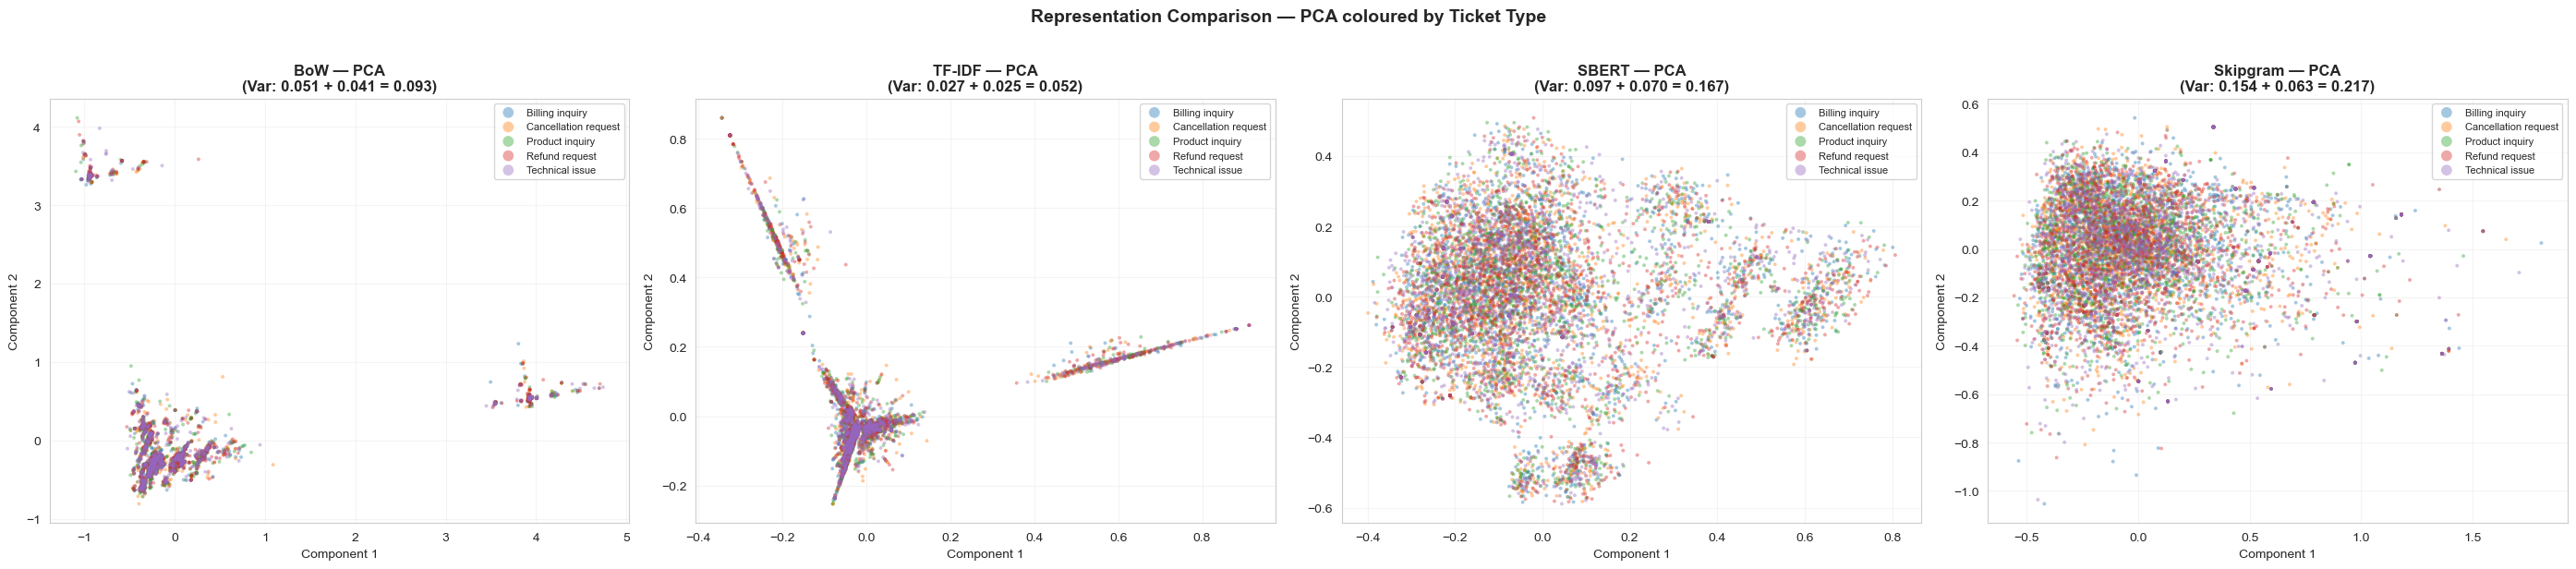

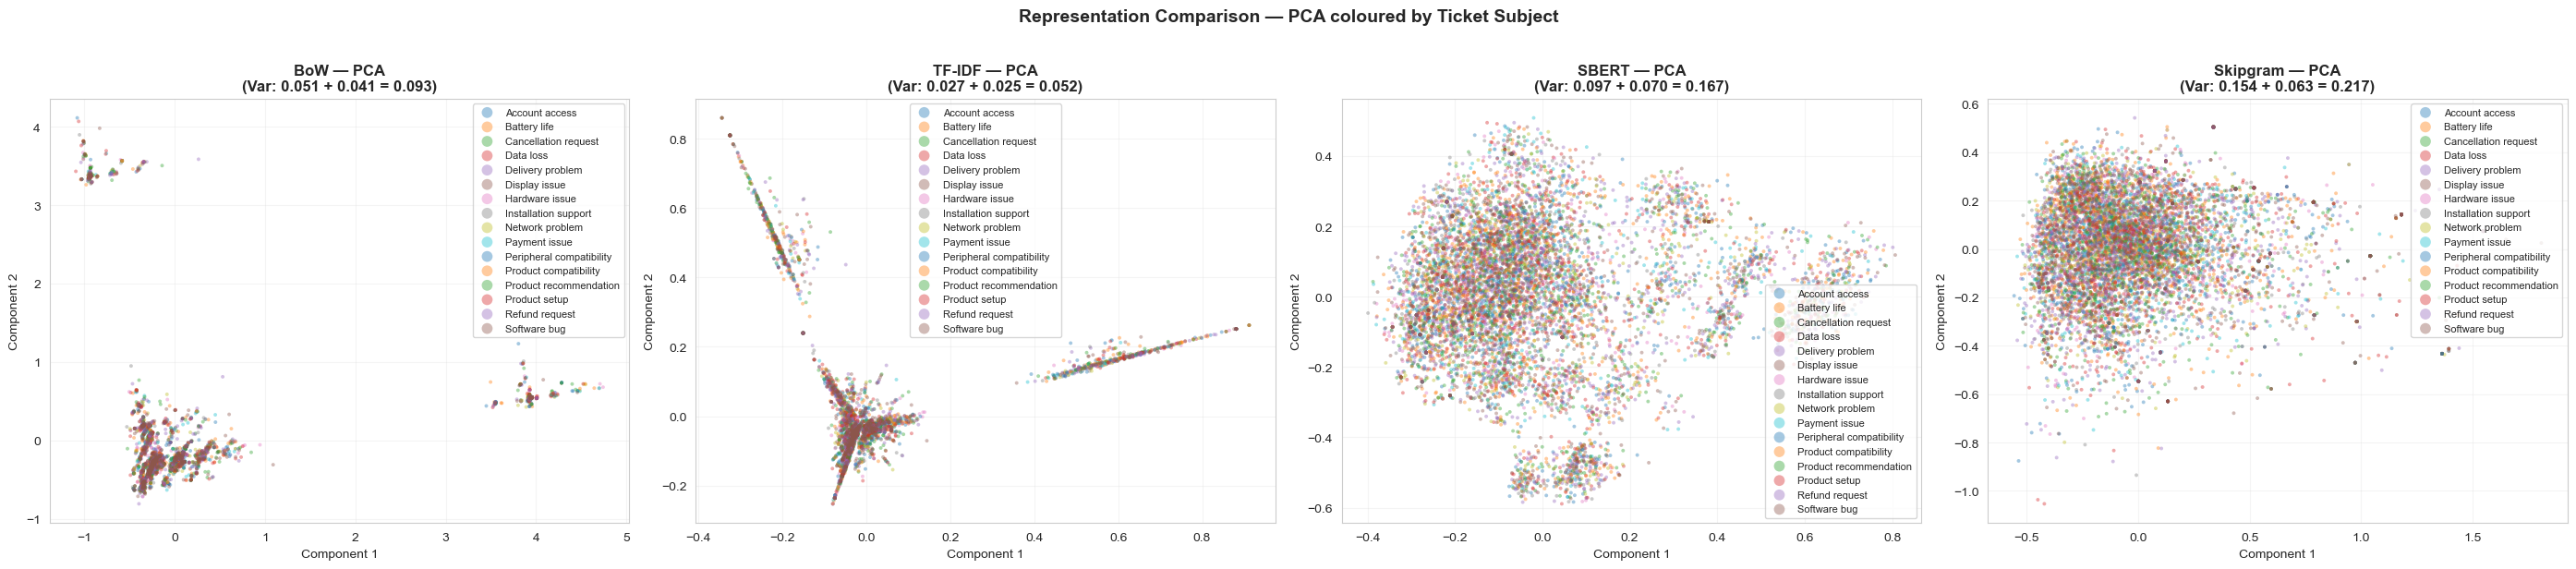

In [11]:
def compare_pca(representations, df, label_col='Ticket Type'):
    n = len(representations)
    fig, axes = plt.subplots(1, n, figsize=(7*n, 6))
    if n == 1: axes = [axes]
    labels = df[label_col].values
    unique_labels = sorted(set(labels))
    palette = sns.color_palette('tab10', len(unique_labels))
    for ax, (X, name) in zip(axes, representations):
        X_dense = X.toarray() if hasattr(X, 'toarray') else np.array(X)
        pca = PCA(n_components=2, random_state=42)
        X_2d = pca.fit_transform(X_dense)
        ev = pca.explained_variance_ratio_
        for i, label in enumerate(unique_labels):
            mask = labels == label
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[palette[i]],
                      label=label, alpha=0.4, s=8, edgecolors='none')
        ax.set_title(f'{name} — PCA\n(Var: {ev[0]:.3f} + {ev[1]:.3f} = {sum(ev):.3f})',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.legend(fontsize=8, markerscale=3)
        ax.grid(True, alpha=0.2)
    fig.suptitle(f'Representation Comparison — PCA coloured by {label_col}',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

reps = [(X_bow, 'BoW'), (X_tfidf, 'TF-IDF'), (X_sbert, 'SBERT'), (X_skipgram, 'Skipgram')]
compare_pca(reps, df, 'Ticket Type')
compare_pca(reps, df, 'Ticket Subject')


# 4. Part 1 — Clustering Analysis

In [12]:
def run_clustering_sweep(X, y_type, y_subj, name, metric='cosine', k_range=range(2, 11)):
    X_dense = X.toarray() if hasattr(X, 'toarray') else np.array(X)
    results = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km_labels = km.fit_predict(X_dense)
        km_sil = silhouette_score(X_dense, km_labels, sample_size=2000, metric=metric)
        km_ari_type = adjusted_rand_score(y_type, km_labels)
        km_nmi_type = normalized_mutual_info_score(y_type, km_labels)
        km_ari_subj = adjusted_rand_score(y_subj, km_labels)
        km_nmi_subj = normalized_mutual_info_score(y_subj, km_labels)
        results.append({'Representation': name, 'Algorithm': 'KMeans', 'k': k,
            'Silhouette': km_sil, 'ARI (Type)': km_ari_type, 'NMI (Type)': km_nmi_type,
            'ARI (Subject)': km_ari_subj, 'NMI (Subject)': km_nmi_subj})
        hac = AgglomerativeClustering(n_clusters=k, linkage='ward')
        hac_labels = hac.fit_predict(X_dense)
        hac_sil = silhouette_score(X_dense, hac_labels, sample_size=2000, metric=metric)
        hac_ari_type = adjusted_rand_score(y_type, hac_labels)
        hac_nmi_type = normalized_mutual_info_score(y_type, hac_labels)
        hac_ari_subj = adjusted_rand_score(y_subj, hac_labels)
        hac_nmi_subj = normalized_mutual_info_score(y_subj, hac_labels)
        results.append({'Representation': name, 'Algorithm': 'HAC', 'k': k,
            'Silhouette': hac_sil, 'ARI (Type)': hac_ari_type, 'NMI (Type)': hac_nmi_type,
            'ARI (Subject)': hac_ari_subj, 'NMI (Subject)': hac_nmi_subj})
    return pd.DataFrame(results)

le = LabelEncoder()
y_type = le.fit_transform(df['Ticket Type'])
y_subj = le.fit_transform(df['Ticket Subject'])

print("Running clustering sweeps...")
df_tfidf = run_clustering_sweep(X_tfidf, y_type, y_subj, 'TF-IDF', metric='cosine')
df_sbert = run_clustering_sweep(X_sbert, y_type, y_subj, 'SBERT', metric='cosine')
df_bow = run_clustering_sweep(X_bow, y_type, y_subj, 'BoW', metric='cosine')
df_skip = run_clustering_sweep(X_skipgram, y_type, y_subj, 'Skipgram', metric='cosine')
all_results = pd.concat([df_tfidf, df_sbert, df_bow, df_skip], ignore_index=True)
print(f"Done. Total runs: {len(all_results)}")


Running clustering sweeps...
Done. Total runs: 72


In [13]:
summary = (all_results.groupby(['Representation', 'Algorithm'])
           .apply(lambda g: g.loc[g['Silhouette'].idxmax()])
           .reset_index(drop=True)
           [['Representation', 'Algorithm', 'k', 'Silhouette', 'ARI (Type)', 'NMI (Type)', 'ARI (Subject)', 'NMI (Subject)']]
           .sort_values('Silhouette', ascending=False))
print("=== Best Clustering Results by Representation ===")
display(summary.round(4))


=== Best Clustering Results by Representation ===


/var/folders/tf/r3_0tdhx5sq5pdqx8lk8bb200000gn/T/ipykernel_14240/3992943859.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g['Silhouette'].idxmax()])


,Representation,Algorithm,k,Silhouette,ARI (Type),NMI (Type),ARI (Subject),NMI (Subject)
2,SBERT,HAC,10,0.2480,0.0002,0.0011,0.0000,0.0031
3,SBERT,KMeans,3,0.2193,0.0003,0.0005,-0.0000,0.0006
1,BoW,KMeans,10,0.1833,-0.0001,0.0016,-0.0000,0.0040
0,BoW,HAC,10,0.1546,-0.0001,0.0015,-0.0001,0.0036
7,TF-IDF,KMeans,10,0.1399,0.0003,0.0013,0.0001,0.0037
5,Skipgram,KMeans,9,0.0986,0.0000,0.0011,0.0002,0.0030
6,TF-IDF,HAC,9,0.0923,0.0003,0.0015,-0.0000,0.0036
4,Skipgram,HAC,5,0.0699,-0.0001,0.0002,-0.0000,0.0015


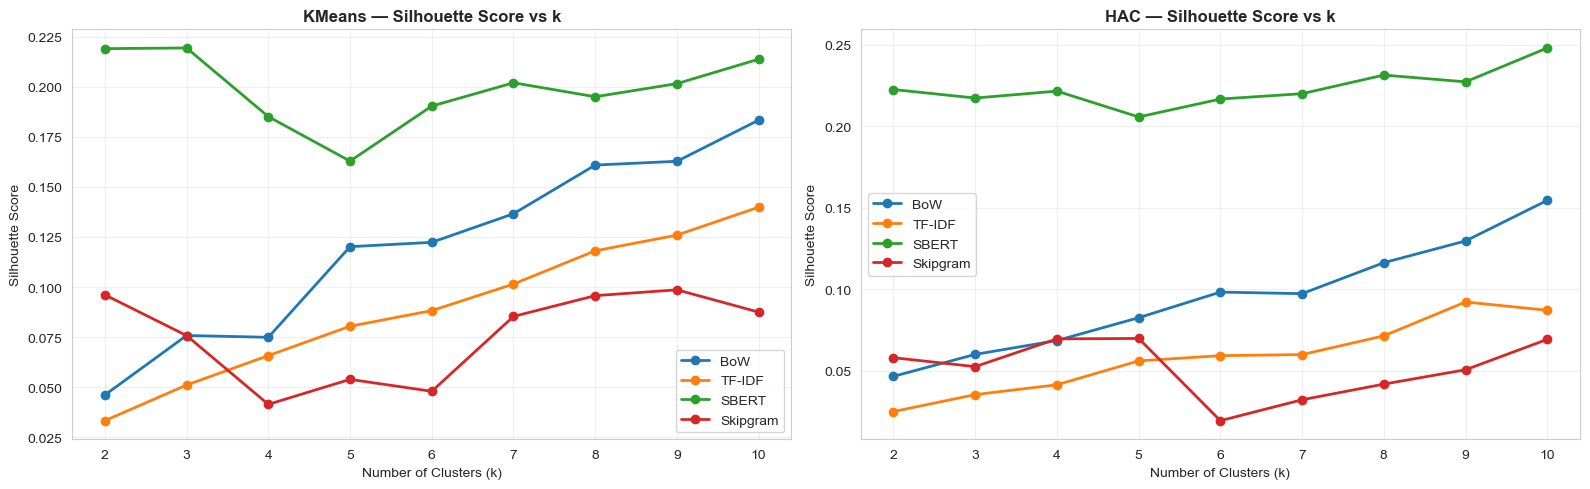

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, algo in zip(axes, ['KMeans', 'HAC']):
    subset = all_results[all_results['Algorithm'] == algo]
    for rep in ['BoW', 'TF-IDF', 'SBERT', 'Skipgram']:
        rep_data = subset[subset['Representation'] == rep]
        ax.plot(rep_data['k'], rep_data['Silhouette'], marker='o', label=rep, linewidth=2)
    ax.set_title(f'{algo} — Silhouette Score vs k', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel('Silhouette Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(2, 11))
plt.tight_layout()
plt.show()


## 4.1 Cluster Interpretability

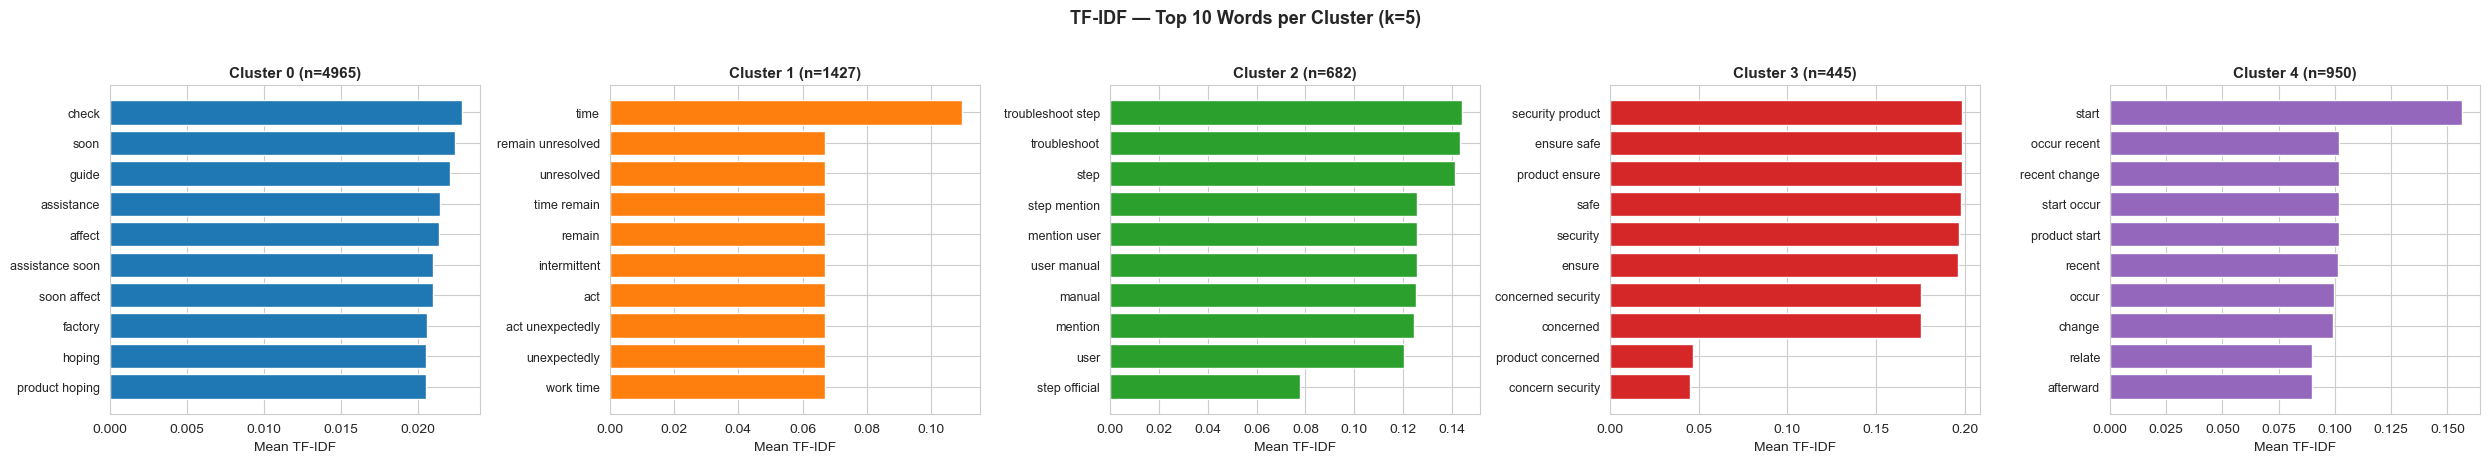

In [15]:
km_tfidf_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
km_tfidf_labels = km_tfidf_5.fit_predict(X_tfidf.toarray())
km_sbert_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
km_sbert_labels = km_sbert_5.fit_predict(X_sbert)

def plot_cluster_top_words(X, cluster_labels, vectorizer, n_top=10, title_prefix="TF-IDF"):
    feature_names = vectorizer.get_feature_names_out()
    X_dense = X.toarray() if hasattr(X, 'toarray') else X
    n_clusters = len(set(cluster_labels))
    fig, axes = plt.subplots(1, n_clusters, figsize=(5*n_clusters, 4.5))
    if n_clusters == 1: axes = [axes]
    for c in sorted(set(cluster_labels)):
        mask = cluster_labels == c
        cluster_mean = X_dense[mask].mean(axis=0)
        if hasattr(cluster_mean, 'A1'): cluster_mean = cluster_mean.A1
        top_idx = cluster_mean.argsort()[-n_top:][::-1]
        ax = axes[c]
        ax.barh(range(n_top), [cluster_mean[i] for i in top_idx],
                color=sns.color_palette('tab10')[c])
        ax.set_yticks(range(n_top))
        ax.set_yticklabels([feature_names[i] for i in top_idx], fontsize=9)
        ax.invert_yaxis()
        ax.set_title(f'Cluster {c} (n={mask.sum()})', fontsize=11, fontweight='bold')
        ax.set_xlabel('Mean TF-IDF')
    fig.suptitle(f'{title_prefix} — Top {n_top} Words per Cluster (k={n_clusters})',
                fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_cluster_top_words(X_tfidf, km_tfidf_labels, tfidf_vectorizer)


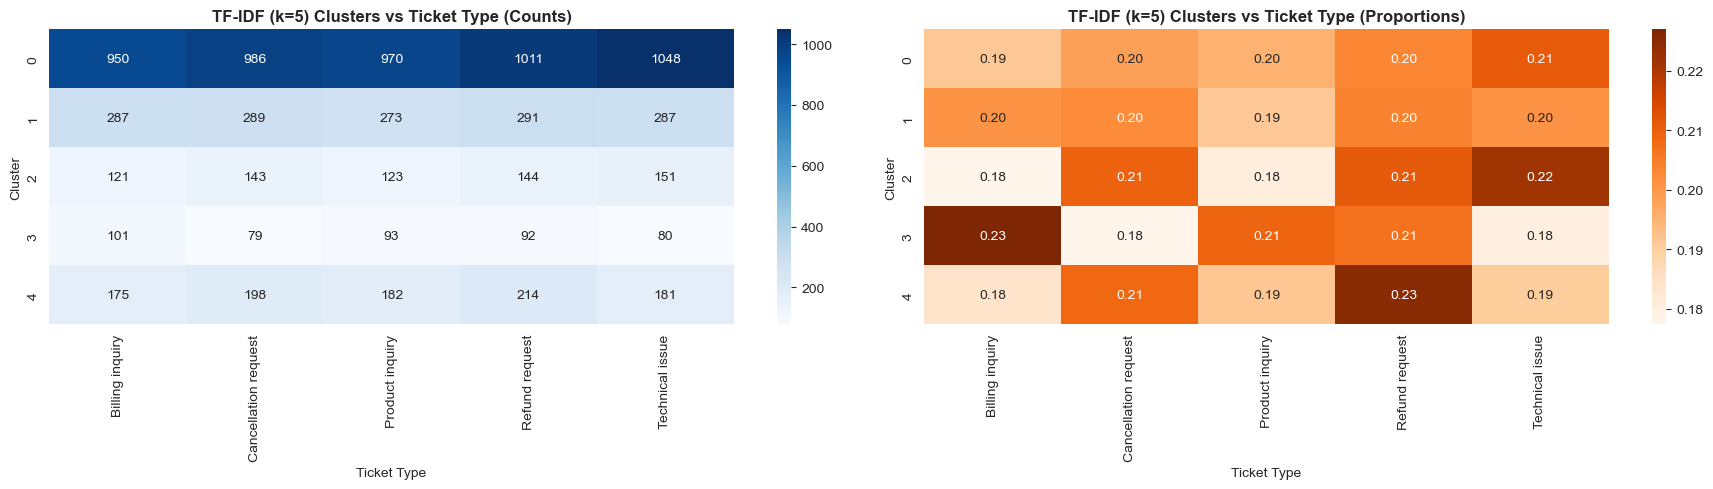

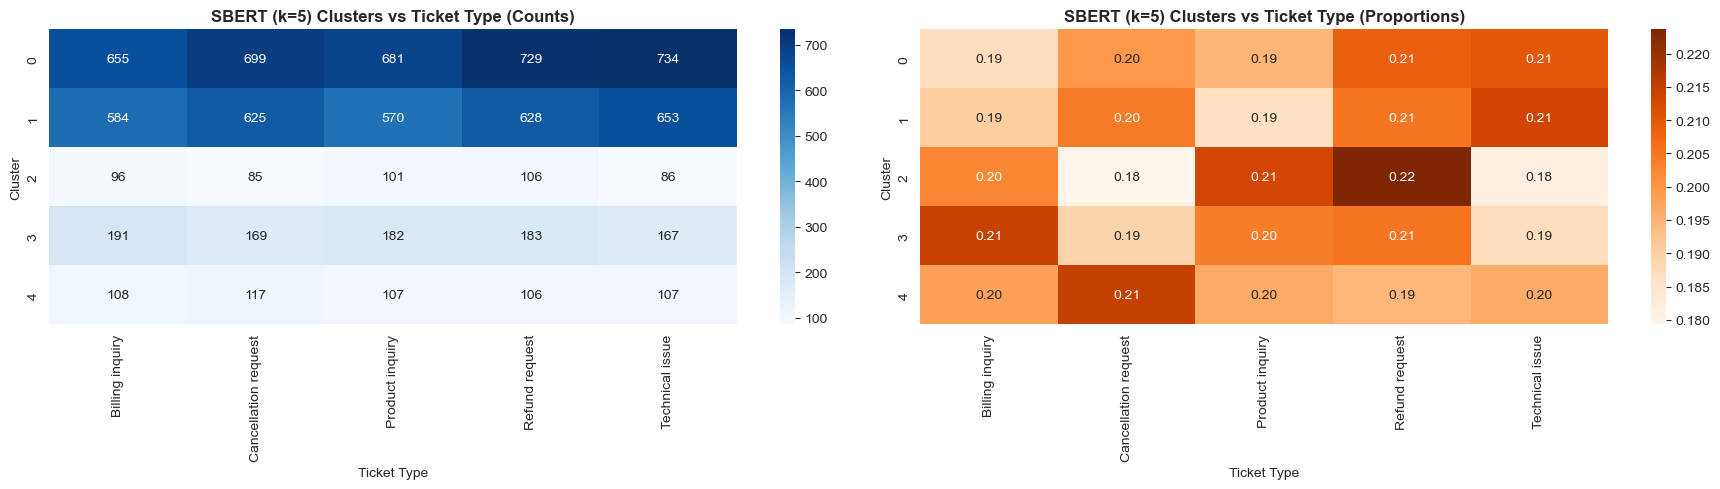

In [16]:
def plot_cluster_heatmaps(cluster_labels, df, title_prefix="TF-IDF"):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    ct = pd.crosstab(cluster_labels, df['Ticket Type'])
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'{title_prefix} Clusters vs Ticket Type (Counts)', fontweight='bold')
    axes[0].set_ylabel('Cluster')
    sns.heatmap(ct_norm, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1])
    axes[1].set_title(f'{title_prefix} Clusters vs Ticket Type (Proportions)', fontweight='bold')
    axes[1].set_ylabel('Cluster')
    plt.tight_layout()
    plt.show()

plot_cluster_heatmaps(km_tfidf_labels, df, "TF-IDF (k=5)")
plot_cluster_heatmaps(km_sbert_labels, df, "SBERT (k=5)")


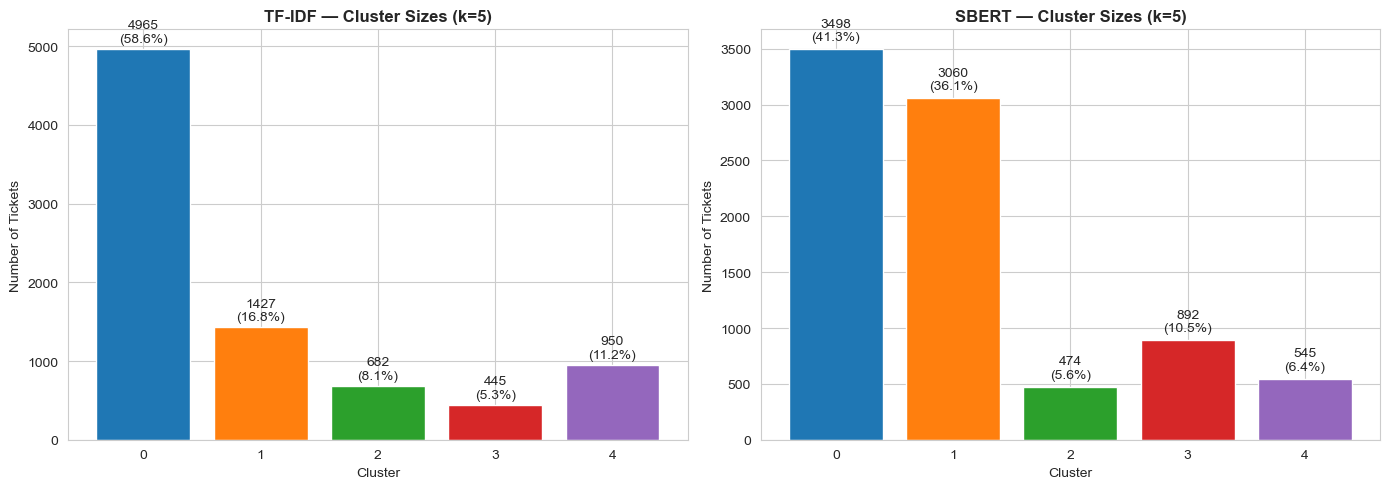

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (labels, name) in zip(axes, [(km_tfidf_labels, "TF-IDF"), (km_sbert_labels, "SBERT")]):
    unique, counts = np.unique(labels, return_counts=True)
    colors = sns.color_palette('tab10', len(unique))
    bars = ax.bar(unique, counts, color=colors)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count}\n({count/len(labels)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{name} — Cluster Sizes (k=5)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Number of Tickets')
plt.tight_layout()
plt.show()


## 4.2 Cluster Stability Across k

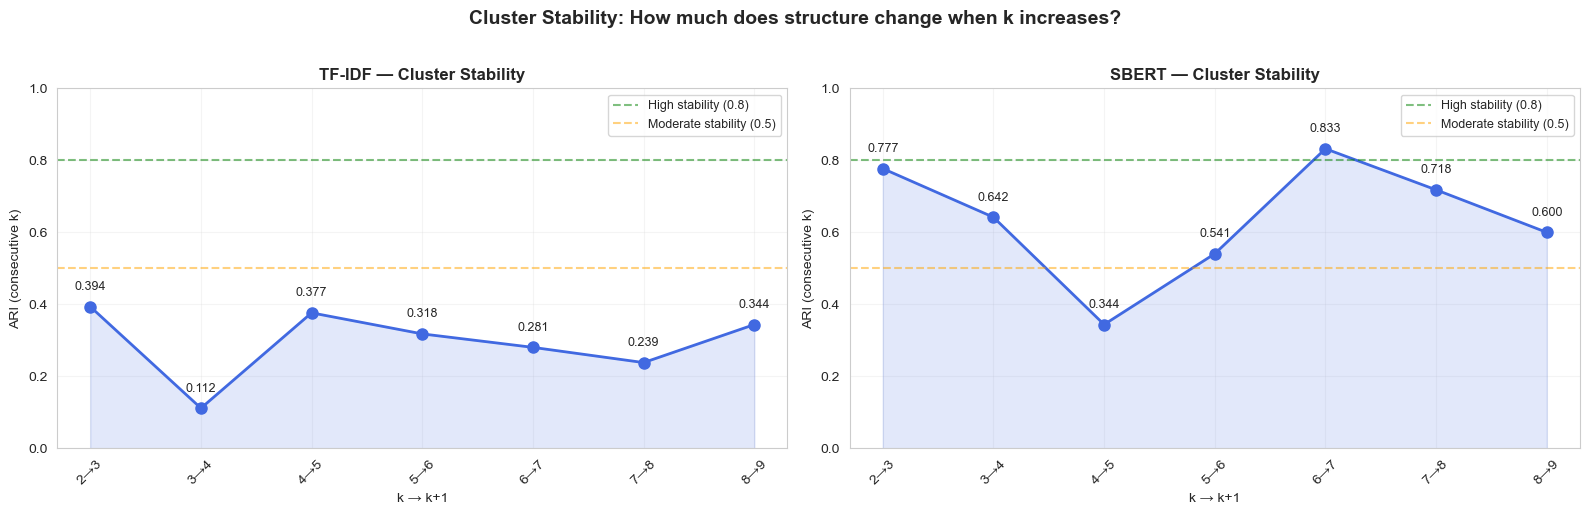

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (name, X_rep) in zip(axes, [("TF-IDF", X_tfidf), ("SBERT", X_sbert)]):
    X_dense = X_rep.toarray() if hasattr(X_rep, 'toarray') else np.array(X_rep)
    k_labels = {}
    for k in range(2, 10):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        k_labels[k] = km.fit_predict(X_dense)
    k_pairs = list(range(2, 9))
    ari_scores = [adjusted_rand_score(k_labels[k], k_labels[k+1]) for k in k_pairs]
    ax.plot(k_pairs, ari_scores, marker='o', linewidth=2, markersize=8, color='royalblue')
    ax.fill_between(k_pairs, ari_scores, alpha=0.15, color='royalblue')
    for k, ari in zip(k_pairs, ari_scores):
        ax.annotate(f'{ari:.3f}', (k, ari), textcoords="offset points",
                    xytext=(0, 12), ha='center', fontsize=9)
    ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='High stability (0.8)')
    ax.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Moderate stability (0.5)')
    ax.set_title(f'{name} — Cluster Stability', fontsize=12, fontweight='bold')
    ax.set_xlabel('k → k+1')
    ax.set_ylabel('ARI (consecutive k)')
    ax.set_xticks(k_pairs)
    ax.set_xticklabels([f'{k}→{k+1}' for k in k_pairs], rotation=45)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)
plt.suptitle('Cluster Stability: How much does structure change when k increases?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# 5. Part 2 — Design Axes

## Axis 1: Topic Discovery — LDA vs BERTopic

**Hypothesis:** LDA will produce more interpretable topics from word co-occurrence patterns. BERTopic may capture finer semantic groupings but risks collapsing homogeneous template text into one mega-topic.


In [19]:
print("=== LDA Topic Modelling ===")
lda_vectorizer = TfidfVectorizer(max_features=3000, min_df=3, max_df=0.85)
X_lda = lda_vectorizer.fit_transform(clean_text)

for n_topics in [5, 8, 10]:
    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20, learning_method='online')
    lda.fit(X_lda)
    feature_names_lda = lda_vectorizer.get_feature_names_out()
    print(f"\n--- LDA with {n_topics} topics ---")
    for topic_idx, topic in enumerate(lda.components_):
        top_words = [feature_names_lda[i] for i in topic.argsort()[-8:][::-1]]
        print(f"  Topic {topic_idx}: {', '.join(top_words)}")


=== LDA Topic Modelling ===

--- LDA with 5 topics ---
  Topic 0: change, occur, user, recent, follow, step, mention, manual
  Topic 1: soon, assistance, factory, affect, hoping, happen, perform, update
  Topic 2: say, error, screen, message, notice, mean, pop, peculiar
  Topic 3: time, work, remain, unresolved, contact, intermittent, act, unexpectedly
  Topic 4: network, connect, step, application, guide, feature, require, desire

--- LDA with 8 topics ---
  Topic 0: happen, firmware, relate, update, afterward, recently, start, productpurchased
  Topic 1: work, intermittent, act, unexpectedly, ensure, security, safe, password
  Topic 2: check, version, run, updates, late, model, widespread, log
  Topic 3: step, troubleshoot, connect, user, network, mention, manual, review
  Topic 4: factory, hoping, perform, application, feature, lose, crash, consistently
  Topic 5: different, setting, sure, access, report, problem, configuration, similar
  Topic 6: screen, change, recent, occur, rema

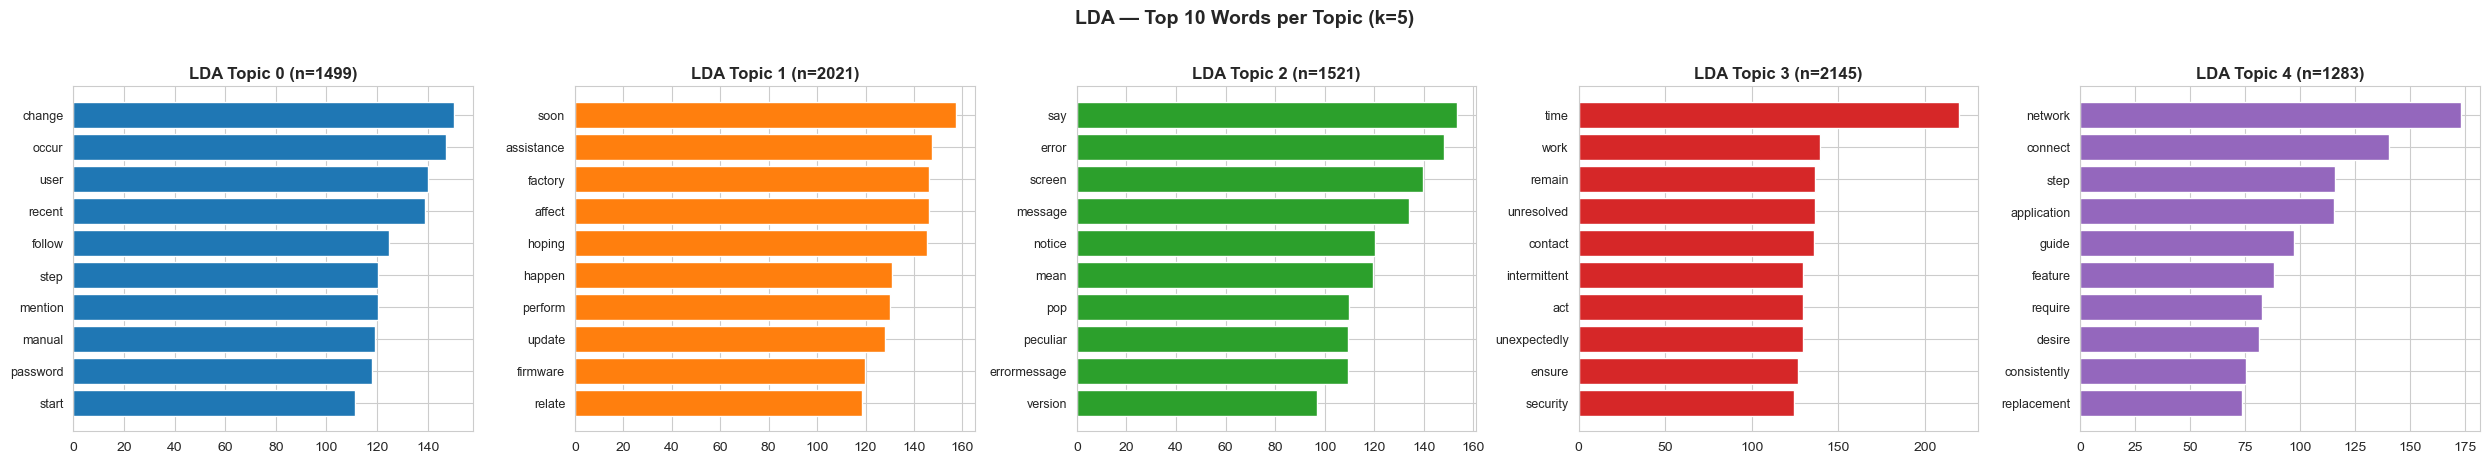


=== LDA Topics vs Ticket Type ===
Ticket Type  Billing inquiry  Cancellation request  Product inquiry  \
row_0                                                                 
0                       0.19                  0.18             0.22   
1                       0.17                  0.22             0.19   
2                       0.19                  0.19             0.18   
3                       0.21                  0.21             0.19   
4                       0.20                  0.20             0.19   

Ticket Type  Refund request  Technical issue  
row_0                                         
0                      0.22             0.20  
1                      0.21             0.21  
2                      0.22             0.21  
3                      0.19             0.20  
4                      0.20             0.21  


In [20]:
lda_5 = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=20, learning_method='online')
lda_topics = lda_5.fit_transform(X_lda)
lda_labels = lda_topics.argmax(axis=1)
feature_names_lda = lda_vectorizer.get_feature_names_out()

fig, axes = plt.subplots(1, 5, figsize=(25, 4.5))
for topic_idx in range(5):
    top_idx = lda_5.components_[topic_idx].argsort()[-10:][::-1]
    top_words = [feature_names_lda[i] for i in top_idx]
    top_weights = [lda_5.components_[topic_idx][i] for i in top_idx]
    axes[topic_idx].barh(range(10), top_weights, color=sns.color_palette('tab10')[topic_idx])
    axes[topic_idx].set_yticks(range(10))
    axes[topic_idx].set_yticklabels(top_words, fontsize=9)
    axes[topic_idx].invert_yaxis()
    n_docs = (lda_labels == topic_idx).sum()
    axes[topic_idx].set_title(f'LDA Topic {topic_idx} (n={n_docs})', fontweight='bold')
fig.suptitle('LDA — Top 10 Words per Topic (k=5)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n=== LDA Topics vs Ticket Type ===")
ct_lda = pd.crosstab(lda_labels, df['Ticket Type'])
ct_lda_norm = ct_lda.div(ct_lda.sum(axis=1), axis=0)
print(ct_lda_norm.round(2))


In [21]:
from bertopic import BERTopic

print("=== BERTopic Topic Modelling ===")
topic_model = BERTopic(nr_topics=10, min_topic_size=50, verbose=True)
sbert_text_list = df['Ticket Description'].apply(to_lower).apply(expand_contractions_fn).apply(replace_product_placeholder).apply(remove_noise).tolist()
topics, probs = topic_model.fit_transform(sbert_text_list)

print(f"\nNumber of topics found: {len(set(topics)) - (1 if -1 in topics else 0)}")
print(f"Outlier documents: {(np.array(topics) == -1).sum()}")
topic_info = topic_model.get_topic_info()
print("\n=== BERTopic Topics ===")
for _, row in topic_info.head(12).iterrows():
    if row['Topic'] == -1: continue
    topic_words = topic_model.get_topic(row['Topic'])
    words = ', '.join([w for w, _ in topic_words[:8]])
    print(f"  Topic {row['Topic']} (n={row['Count']}): {words}")


=== BERTopic Topic Modelling ===


2026-04-07 21:28:42,201 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/265 [00:00<?, ?it/s]

2026-04-07 21:28:52,339 - BERTopic - Embedding - Completed ✓
2026-04-07 21:28:52,339 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-07 21:28:59,154 - BERTopic - Dimensionality - Completed ✓
2026-04-07 21:28:59,154 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-07 21:28:59,287 - BERTopic - Cluster - Completed ✓
2026-04-07 21:28:59,287 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-07 21:28:59,369 - BERTopic - Representation - Completed ✓
2026-04-07 21:28:59,369 - BERTopic - Topic reduction - Reducing number of topics
2026-04-07 21:28:59,373 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-07 21:28:59,443 - BERTopic - Representation - Completed ✓
2026-04-07 21:28:59,444 - BERTopic - Topic reduction - Reduced number of topics from 42 to 10



Number of topics found: 9
Outlier documents: 840

=== BERTopic Topics ===
  Topic 0 (n=4630): the, product, issue, please, with, an, am, assist
  Topic 1 (n=529): software, bug, in, the, it, to, there, can
  Topic 2 (n=503): to, network, troubleshoot, networks, this, it, connecting, my
  Topic 3 (n=493): account, my, password, it, access, to, how, can
  Topic 4 (n=454): data, files, deleted, have, to, lost, them, way
  Topic 5 (n=337): the, desired, through, find, guide, action, perform, option
  Topic 6 (n=329): safe, concerned, security, ensure, like, about, would, my
  Topic 7 (n=184): charger, charging, came, original, properly, using, with, am
  Topic 8 (n=170): flickering, hardware, screen, to, seems, should, do, use


=== BERTopic Topics vs Ticket Type ===
col_0  Billing inquiry  Cancellation request  Product inquiry  Refund request  \
row_0                                                                           
0                 0.19                  0.20             0.19            0.21   
1                 0.20                  0.19             0.19            0.20   
2                 0.19                  0.21             0.20            0.19   
3                 0.21                  0.19             0.19            0.21   
4                 0.21                  0.17             0.22            0.22   
5                 0.18                  0.19             0.22            0.18   
6                 0.23                  0.18             0.22            0.19   
7                 0.19                  0.25             0.16            0.20   
8                 0.21                  0.22             0.20            0.18   

col_0  Technical issue  
row_0                   
0                 0

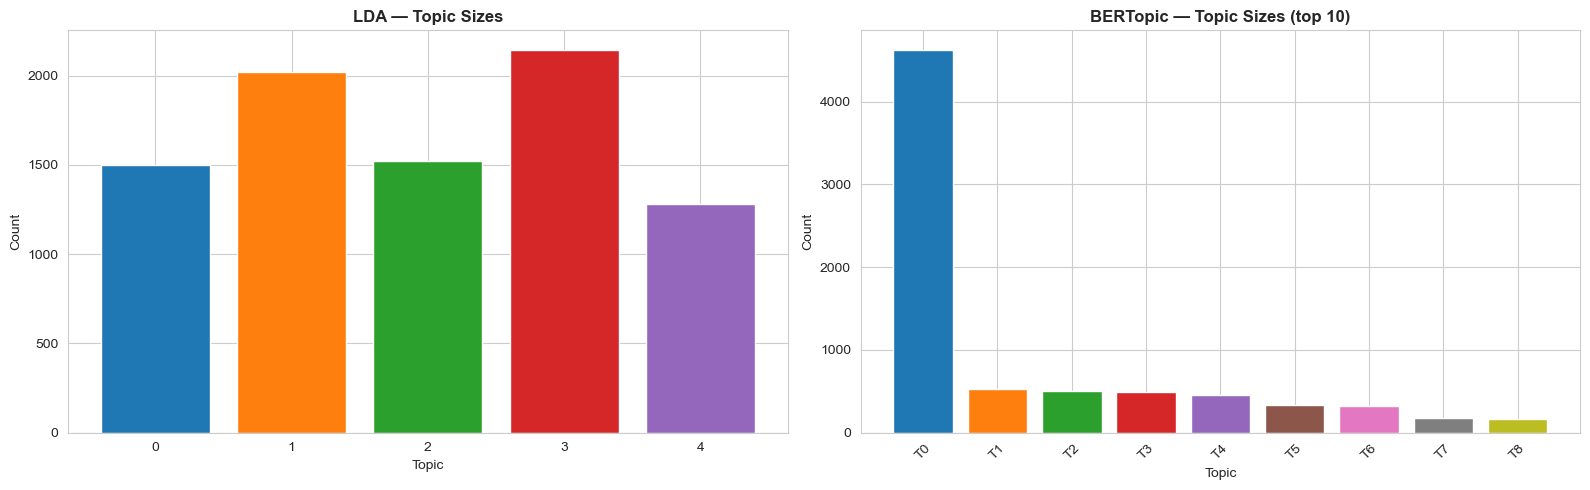

In [22]:
bt_labels = np.array(topics)
valid_mask = bt_labels != -1
print("=== BERTopic Topics vs Ticket Type ===")
ct_bt = pd.crosstab(bt_labels[valid_mask], df['Ticket Type'].values[valid_mask])
ct_bt_norm = ct_bt.div(ct_bt.sum(axis=1), axis=0)
print(ct_bt_norm.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
lda_unique, lda_counts = np.unique(lda_labels, return_counts=True)
axes[0].bar(lda_unique, lda_counts, color=sns.color_palette('tab10', len(lda_unique)))
axes[0].set_title('LDA — Topic Sizes', fontweight='bold')
axes[0].set_xlabel('Topic')
axes[0].set_ylabel('Count')
bt_info = topic_model.get_topic_info()
bt_top = bt_info[bt_info['Topic'] != -1].head(10)
axes[1].bar(range(len(bt_top)), bt_top['Count'].values,
            color=sns.color_palette('tab10', len(bt_top)))
axes[1].set_xticks(range(len(bt_top)))
axes[1].set_xticklabels([f"T{t}" for t in bt_top['Topic'].values], rotation=45)
axes[1].set_title('BERTopic — Topic Sizes (top 10)', fontweight='bold')
axes[1].set_xlabel('Topic')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


## Axis 2: Sentiment Analysis — VADER vs TextBlob

**Hypothesis:** VADER, designed for social media text, will produce a wider sentiment range than TextBlob on this informal support ticket corpus. Both should show uniform sentiment across ticket types in this synthetic dataset.


In [23]:
vader = SentimentIntensityAnalyzer()
df['vader_compound'] = df['Ticket Description'].apply(lambda x: vader.polarity_scores(x)['compound'])
df['vader_label'] = df['vader_compound'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))
df['tb_polarity'] = df['Ticket Description'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['tb_subjectivity'] = df['Ticket Description'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df['tb_label'] = df['tb_polarity'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))

print("=== Sentiment Distribution ===")
print("\nVADER:")
print(df['vader_label'].value_counts())
print("\nTextBlob:")
print(df['tb_label'].value_counts())


=== Sentiment Distribution ===

VADER:
vader_label
Positive    6000
Negative    2109
Neutral      360
Name: count, dtype: int64

TextBlob:
tb_label
Positive    3766
Neutral     2794
Negative    1909
Name: count, dtype: int64


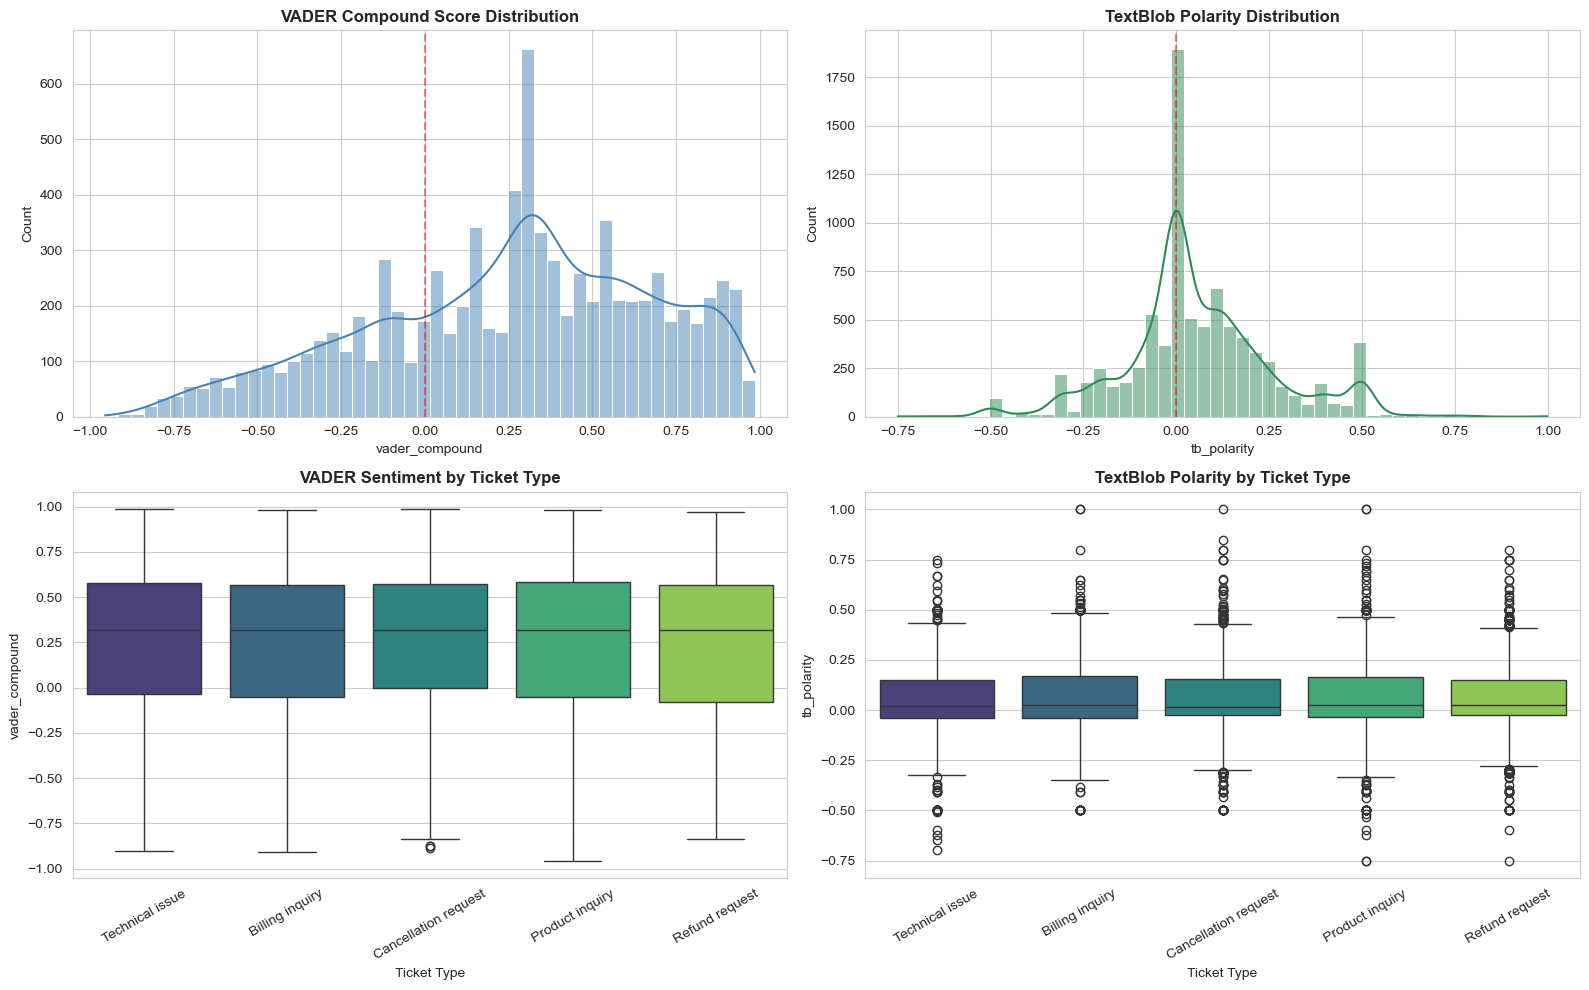

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.histplot(df['vader_compound'], bins=50, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('VADER Compound Score Distribution', fontweight='bold')
axes[0,0].axvline(0, color='red', linestyle='--', alpha=0.5)
sns.histplot(df['tb_polarity'], bins=50, kde=True, ax=axes[0,1], color='seagreen')
axes[0,1].set_title('TextBlob Polarity Distribution', fontweight='bold')
axes[0,1].axvline(0, color='red', linestyle='--', alpha=0.5)
sns.boxplot(data=df, x='Ticket Type', y='vader_compound', ax=axes[1,0], palette='viridis')
axes[1,0].set_title('VADER Sentiment by Ticket Type', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df, x='Ticket Type', y='tb_polarity', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('TextBlob Polarity by Ticket Type', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


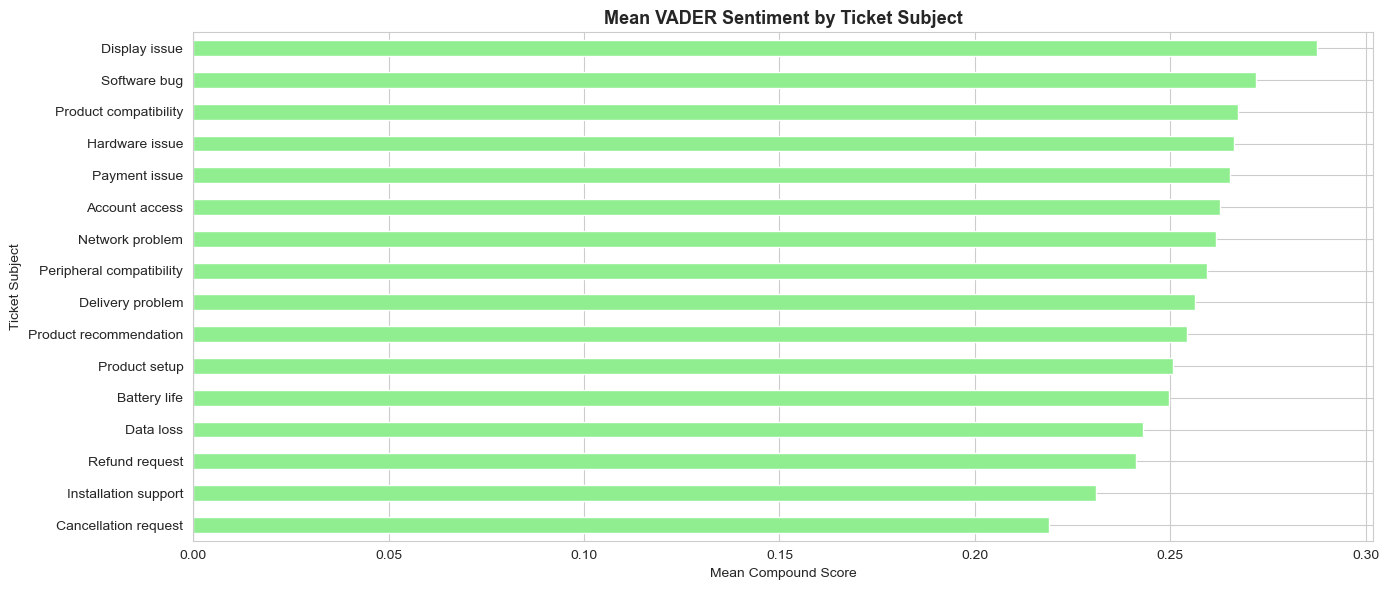

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))
subject_sentiment = df.groupby('Ticket Subject')['vader_compound'].mean().sort_values()
subject_sentiment.plot(kind='barh', ax=ax, color=[
    'salmon' if v < -0.05 else ('lightgreen' if v > 0.05 else 'lightgray')
    for v in subject_sentiment.values])
ax.set_title('Mean VADER Sentiment by Ticket Subject', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Compound Score')
ax.axvline(0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()


=== Sentiment by LDA Topic ===
           Mean Sentiment  Std Sentiment  Count
lda_topic                                      
0                   0.132          0.463   1499
1                   0.279          0.376   2021
2                   0.159          0.427   1521
3                   0.383          0.388   2145
4                   0.263          0.426   1283


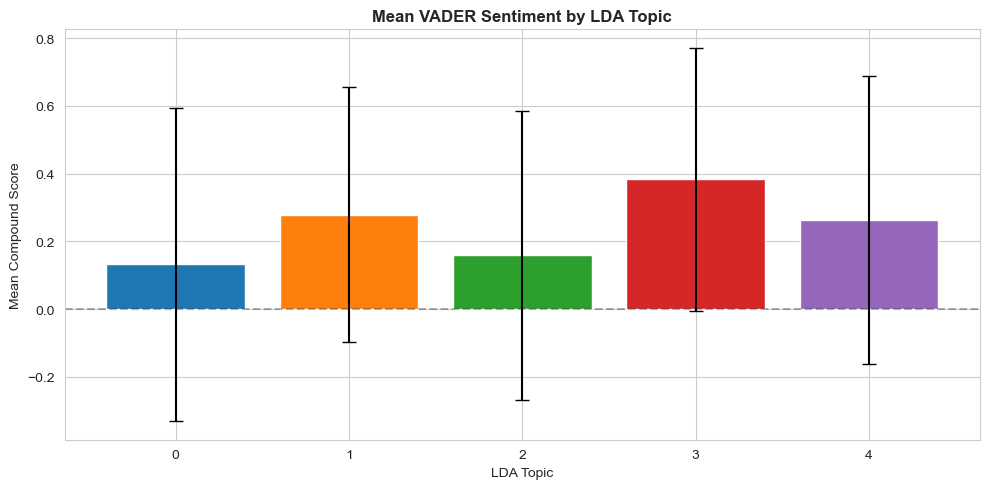

In [26]:
df['lda_topic'] = lda_labels
fig, ax = plt.subplots(figsize=(10, 5))
topic_sentiment = df.groupby('lda_topic')['vader_compound'].agg(['mean', 'std', 'count'])
topic_sentiment.columns = ['Mean Sentiment', 'Std Sentiment', 'Count']
print("=== Sentiment by LDA Topic ===")
print(topic_sentiment.round(3))
ax.bar(topic_sentiment.index, topic_sentiment['Mean Sentiment'],
       yerr=topic_sentiment['Std Sentiment'], capsize=5,
       color=sns.color_palette('tab10', len(topic_sentiment)))
ax.set_title('Mean VADER Sentiment by LDA Topic', fontweight='bold')
ax.set_xlabel('LDA Topic')
ax.set_ylabel('Mean Compound Score')
ax.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# 5.1 Consistency & Robustness Across Methods (Requirement 4a)

SENTIMENT CONSISTENCY: VADER vs TextBlob
Pearson correlation:  r = 0.332  (p = 2.33e-217)
Spearman correlation: r = 0.316  (p = 1.95e-195)

Label agreement (Pos/Neg/Neutral): 45.6%

Sentiment Label Cross-tab:
TextBlob  Negative  Neutral  Positive
VADER                                
Negative       751      751       607
Neutral         84      114       162
Positive      1074     1929      2997


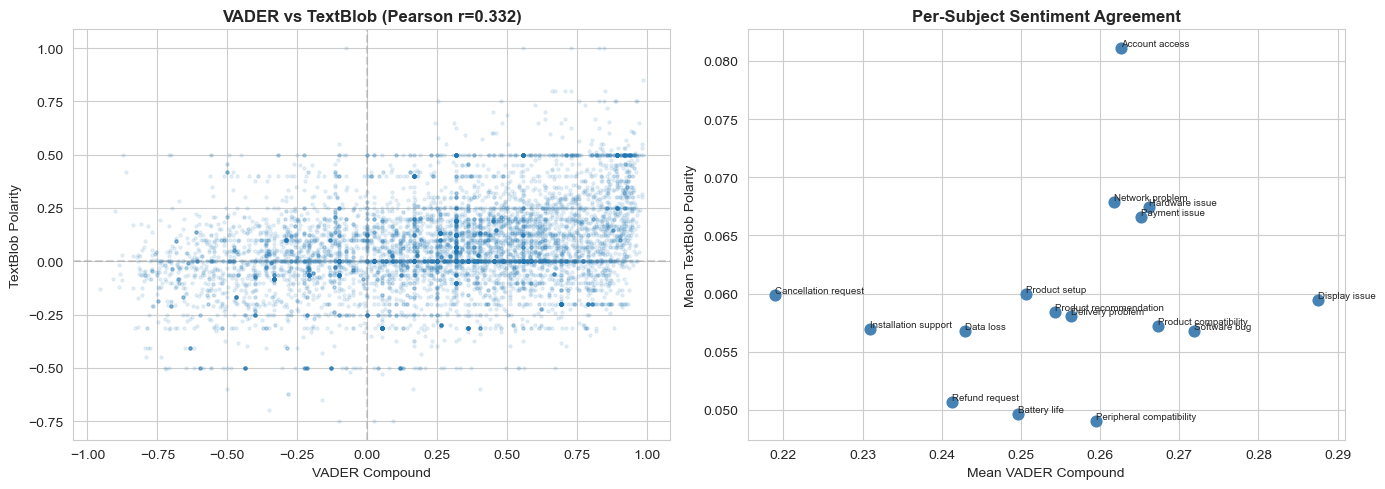

In [27]:
print("=" * 60)
print("SENTIMENT CONSISTENCY: VADER vs TextBlob")
print("=" * 60)

r_pearson, p_pearson = pearsonr(df['vader_compound'], df['tb_polarity'])
r_spearman, p_spearman = spearmanr(df['vader_compound'], df['tb_polarity'])
print(f"Pearson correlation:  r = {r_pearson:.3f}  (p = {p_pearson:.2e})")
print(f"Spearman correlation: r = {r_spearman:.3f}  (p = {p_spearman:.2e})")

agreement = (df['vader_label'] == df['tb_label']).mean()
print(f"\nLabel agreement (Pos/Neg/Neutral): {agreement:.1%}")
print("\nSentiment Label Cross-tab:")
print(pd.crosstab(df['vader_label'], df['tb_label'], rownames=['VADER'], colnames=['TextBlob']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['vader_compound'], df['tb_polarity'], alpha=0.1, s=5)
axes[0].set_xlabel('VADER Compound')
axes[0].set_ylabel('TextBlob Polarity')
axes[0].set_title(f'VADER vs TextBlob (Pearson r={r_pearson:.3f})', fontweight='bold')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.3)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.3)

subject_vader = df.groupby('Ticket Subject')['vader_compound'].mean()
subject_tb = df.groupby('Ticket Subject')['tb_polarity'].mean()
axes[1].scatter(subject_vader, subject_tb, s=60, c='steelblue')
for subj in subject_vader.index:
    axes[1].annotate(subj, (subject_vader[subj], subject_tb[subj]),
                     fontsize=7, ha='left', va='bottom')
axes[1].set_xlabel('Mean VADER Compound')
axes[1].set_ylabel('Mean TextBlob Polarity')
axes[1].set_title('Per-Subject Sentiment Agreement', fontweight='bold')
plt.tight_layout()
plt.show()


TOPIC MODEL vs CLUSTERING ALIGNMENT

LDA Topics vs TF-IDF Clusters (counts):
TF-IDF Cluster     0    1    2    3    4
LDA Topic                               
0                677   79  377   32  334
1               1464   66   34   25  432
2                902  502   36   33   48
3                899  689  186  314   57
4               1023   91   49   41   79

LDA Topics vs TF-IDF Clusters (proportions):
TF-IDF Cluster     0     1     2     3     4
LDA Topic                                   
0               0.45  0.05  0.25  0.02  0.22
1               0.72  0.03  0.02  0.01  0.21
2               0.59  0.33  0.02  0.02  0.03
3               0.42  0.32  0.09  0.15  0.03
4               0.80  0.07  0.04  0.03  0.06

ARI (LDA vs TF-IDF KMeans): 0.0471
NMI (LDA vs TF-IDF KMeans): 0.1257

ARI (LDA vs SBERT KMeans): 0.0483
NMI (LDA vs SBERT KMeans): 0.1253


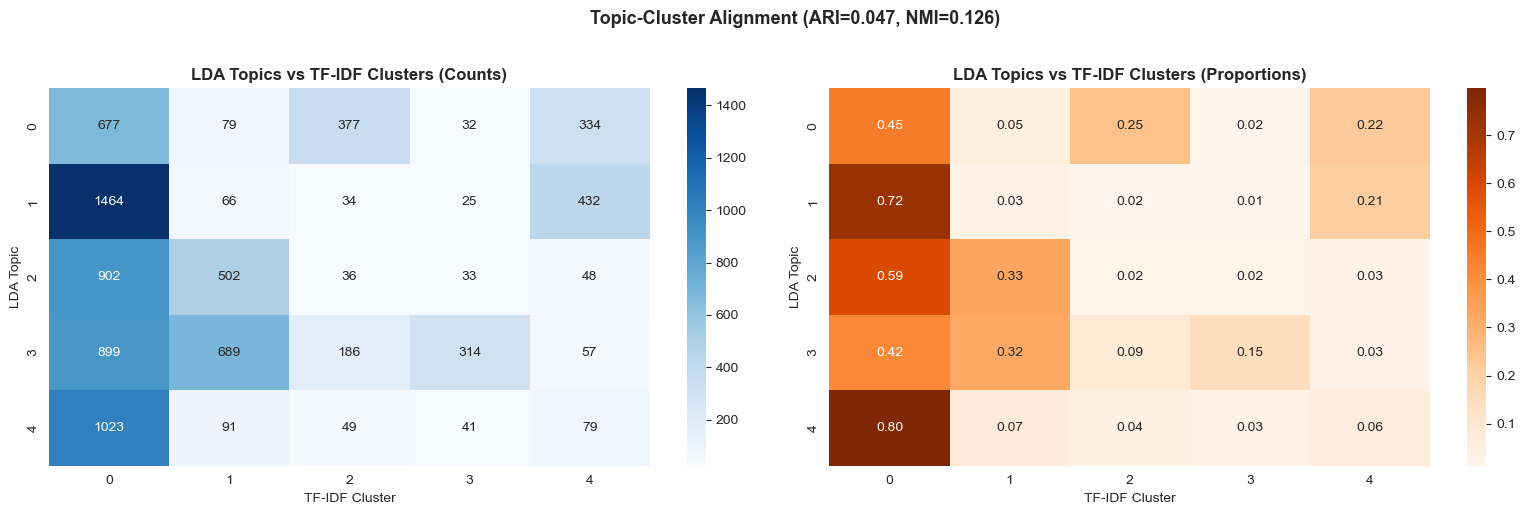

In [28]:
print("=" * 60)
print("TOPIC MODEL vs CLUSTERING ALIGNMENT")
print("=" * 60)

ct_lda_km = pd.crosstab(lda_labels, km_tfidf_labels,
                          rownames=['LDA Topic'], colnames=['TF-IDF Cluster'])
print("\nLDA Topics vs TF-IDF Clusters (counts):")
print(ct_lda_km)
ct_lda_km_norm = ct_lda_km.div(ct_lda_km.sum(axis=1), axis=0)
print("\nLDA Topics vs TF-IDF Clusters (proportions):")
print(ct_lda_km_norm.round(2))

ari_lda_km = adjusted_rand_score(lda_labels, km_tfidf_labels)
nmi_lda_km = normalized_mutual_info_score(lda_labels, km_tfidf_labels)
print(f"\nARI (LDA vs TF-IDF KMeans): {ari_lda_km:.4f}")
print(f"NMI (LDA vs TF-IDF KMeans): {nmi_lda_km:.4f}")

ari_lda_sbert = adjusted_rand_score(lda_labels, km_sbert_labels)
nmi_lda_sbert = normalized_mutual_info_score(lda_labels, km_sbert_labels)
print(f"\nARI (LDA vs SBERT KMeans): {ari_lda_sbert:.4f}")
print(f"NMI (LDA vs SBERT KMeans): {nmi_lda_sbert:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(ct_lda_km, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('LDA Topics vs TF-IDF Clusters (Counts)', fontweight='bold')
sns.heatmap(ct_lda_km_norm, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1])
axes[1].set_title('LDA Topics vs TF-IDF Clusters (Proportions)', fontweight='bold')
plt.suptitle(f'Topic-Cluster Alignment (ARI={ari_lda_km:.3f}, NMI={nmi_lda_km:.3f})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [29]:
print("=" * 60)
print("BERTOPIC vs LDA ALIGNMENT")
print("=" * 60)

bt_labels_clean = np.array(topics)
valid = bt_labels_clean != -1
ari_bt_lda = adjusted_rand_score(lda_labels[valid], bt_labels_clean[valid])
nmi_bt_lda = normalized_mutual_info_score(lda_labels[valid], bt_labels_clean[valid])
print(f"ARI (BERTopic vs LDA): {ari_bt_lda:.4f}")
print(f"NMI (BERTopic vs LDA): {nmi_bt_lda:.4f}")
print(f"BERTopic outliers excluded: {(~valid).sum()} / {len(valid)}")

print("\n" + "=" * 60)
print("CROSS-METHOD AGREEMENT SUMMARY")
print("=" * 60)
comparisons = pd.DataFrame([
    {'Comparison': 'LDA vs TF-IDF KMeans', 'ARI': f'{ari_lda_km:.4f}', 'NMI': f'{nmi_lda_km:.4f}'},
    {'Comparison': 'LDA vs SBERT KMeans', 'ARI': f'{ari_lda_sbert:.4f}', 'NMI': f'{nmi_lda_sbert:.4f}'},
    {'Comparison': 'BERTopic vs LDA', 'ARI': f'{ari_bt_lda:.4f}', 'NMI': f'{nmi_bt_lda:.4f}'},
    {'Comparison': 'VADER vs TextBlob', 'ARI': '-', 'NMI': f'r={r_pearson:.3f}'},
])
print(comparisons.to_string(index=False))


BERTOPIC vs LDA ALIGNMENT
ARI (BERTopic vs LDA): 0.0835
NMI (BERTopic vs LDA): 0.1996
BERTopic outliers excluded: 840 / 8469

CROSS-METHOD AGREEMENT SUMMARY
          Comparison    ARI     NMI
LDA vs TF-IDF KMeans 0.0471  0.1257
 LDA vs SBERT KMeans 0.0483  0.1253
     BERTopic vs LDA 0.0835  0.1996
   VADER vs TextBlob      - r=0.332


# 6. Actionable Insights

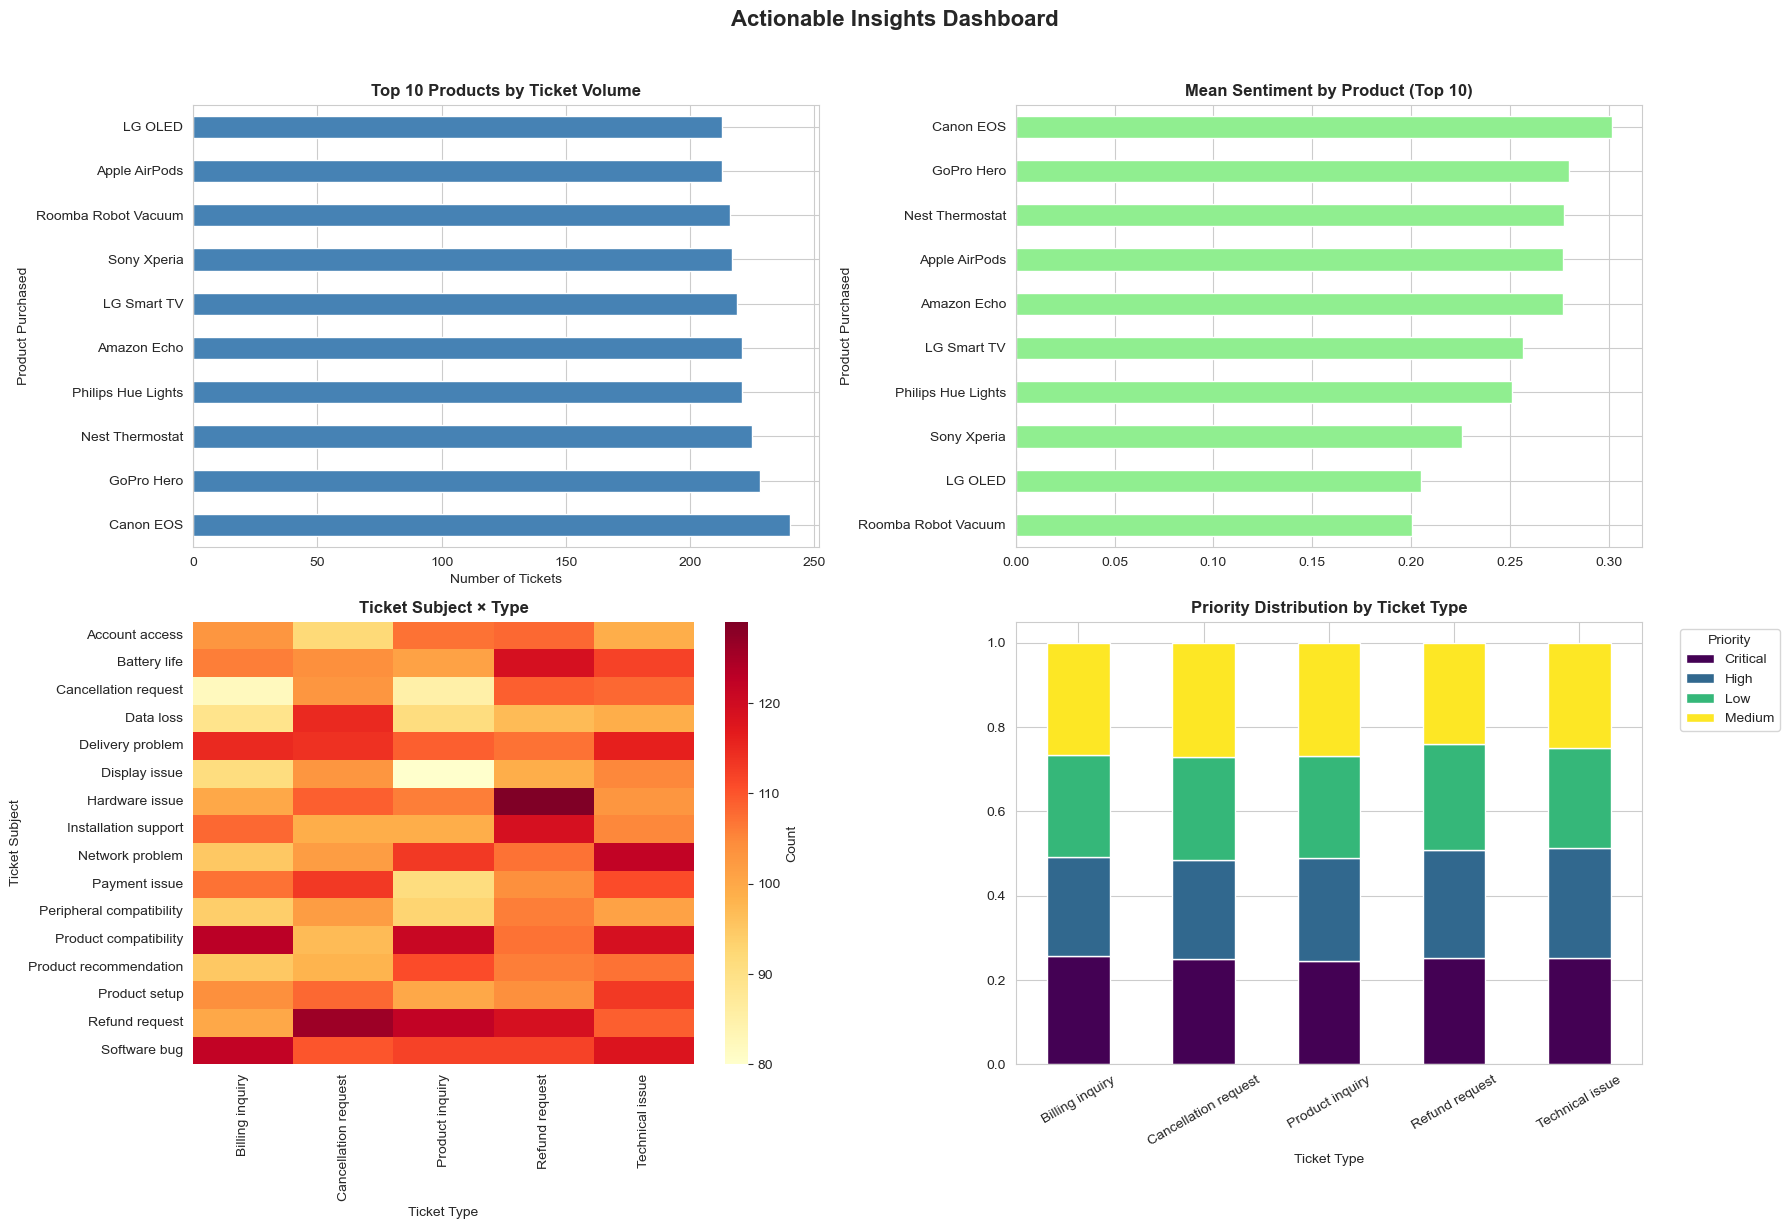

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
product_counts = df['Product Purchased'].value_counts().head(10)
product_counts.plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top 10 Products by Ticket Volume', fontweight='bold')
axes[0,0].set_xlabel('Number of Tickets')

top_products = df['Product Purchased'].value_counts().head(10).index
product_sentiment = (df[df['Product Purchased'].isin(top_products)]
                     .groupby('Product Purchased')['vader_compound'].mean().sort_values())
product_sentiment.plot(kind='barh', ax=axes[0,1],
                       color=['salmon' if v < 0 else 'lightgreen' for v in product_sentiment.values])
axes[0,1].set_title('Mean Sentiment by Product (Top 10)', fontweight='bold')
axes[0,1].axvline(0, color='black', linestyle='--', alpha=0.3)

ct_ts = pd.crosstab(df['Ticket Subject'], df['Ticket Type'])
sns.heatmap(ct_ts, cmap='YlOrRd', ax=axes[1,0], cbar_kws={'label': 'Count'})
axes[1,0].set_title('Ticket Subject × Type', fontweight='bold')

ct_priority = pd.crosstab(df['Ticket Type'], df['Ticket Priority'], normalize='index')
ct_priority.plot(kind='bar', stacked=True, ax=axes[1,1], colormap='viridis')
axes[1,1].set_title('Priority Distribution by Ticket Type', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(title='Priority', bbox_to_anchor=(1.05, 1))
plt.suptitle('Actionable Insights Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [31]:
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print("\n1. CLUSTERING: SBERT achieves best silhouette (~0.22), TF-IDF most interpretable")
print("2. LABEL INDEPENDENCE: ARI ≈ 0.000 — Ticket Type labels unrelated to text content")
print("3. LDA: Most interpretable topic discovery — finds error, network, security, account themes")
print("4. BERTOPIC: Collapses into one mega-topic — fails on homogeneous template text")
print("5. SENTIMENT: VADER broader range than TextBlob; both uniform across ticket types")
print("6. KEY FINDING: Synthetic dataset has independent labels — no method can recover them")
print("   but topic models successfully discover latent complaint patterns in the text")


FINAL SUMMARY

1. CLUSTERING: SBERT achieves best silhouette (~0.22), TF-IDF most interpretable
2. LABEL INDEPENDENCE: ARI ≈ 0.000 — Ticket Type labels unrelated to text content
3. LDA: Most interpretable topic discovery — finds error, network, security, account themes
4. BERTOPIC: Collapses into one mega-topic — fails on homogeneous template text
5. SENTIMENT: VADER broader range than TextBlob; both uniform across ticket types
6. KEY FINDING: Synthetic dataset has independent labels — no method can recover them
   but topic models successfully discover latent complaint patterns in the text
